# 🛠️ 1) Setup and Libraries

In [ ]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' 

In [9]:
# =========================================================
# 1. System & Utilities
# =========================================================
import os
import time
import random
import math
import pathlib
import itertools
from glob import glob
from tqdm import tqdm_notebook, tnrange
import warnings
warnings.filterwarnings("ignore")

# =========================================================
# 2. Data Handling & Visualization
# =========================================================
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from skimage.color import rgb2gray
from skimage.morphology import label
from skimage.transform import resize
from skimage.io import imread, imshow, concatenate_images
%matplotlib inline
sns.set_style('darkgrid')

# =========================================================
# 3. Machine Learning & Preprocessing
# =========================================================
from sklearn.model_selection import train_test_split

# =========================================================
# 4. Deep Learning (TensorFlow & Keras)
# =========================================================
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import backend as K # مهم جداً للتعامل مع الـ Tensors
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate, Conv2DTranspose, BatchNormalization, Dropout, Lambda
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, LearningRateScheduler, EarlyStopping, ReduceLROnPlateau

# 📂 2) Data Preparation

In [3]:
# function to create dataframe
def create_df(data_dir):
    images_paths = []
    masks_paths = glob(f'{data_dir}/*/*_mask*')

    for i in masks_paths:
        images_paths.append(i.replace('_mask', ''))

    df = pd.DataFrame(data= {'images_paths': images_paths, 'masks_paths': masks_paths})

    return df

# Function to split dataframe into train, valid, test
def split_df(df):
    train_df, dummy_df = train_test_split(df, train_size= 0.8)
    valid_df, test_df = train_test_split(dummy_df, train_size= 0.5)

    return train_df, valid_df, test_df

# 🧪 3) Data Augmentation & Generators

In [16]:
def create_gens(df, aug_dict):
    img_size = (256, 256)
    batch_size = 32

    img_gen = ImageDataGenerator(**aug_dict)
    msk_gen = ImageDataGenerator(**aug_dict)

    image_generator = img_gen.flow_from_dataframe(
        df, x_col='images_paths', class_mode=None, color_mode='rgb', 
        target_size=img_size, batch_size=batch_size, seed=1)

    mask_generator = msk_gen.flow_from_dataframe(
        df, x_col='masks_paths', class_mode=None, color_mode='grayscale', 
        target_size=img_size, batch_size=batch_size, seed=1)

    gen = zip(image_generator, mask_generator)

    while True:
        try:
            img, msk = next(gen)
        except StopIteration:
            image_generator.reset()
            mask_generator.reset()
            gen = zip(image_generator, mask_generator)
            img, msk = next(gen)
        
        img = img / 255.0
        msk = msk / 255.0
        msk[msk > 0.5] = 1
        msk[msk <= 0.5] = 0

        yield (img, msk)

In [17]:
def show_images(images, masks):
    plt.figure(figsize=(12, 12))
    for i in range(25):
        plt.subplot(5, 5, i+1)
        img_path = images[i]
        mask_path = masks[i]

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        mask = cv2.imread(mask_path)
        
        plt.imshow(image)
        plt.imshow(mask, alpha=0.4)

        plt.axis('off')

    plt.tight_layout()
    plt.show()

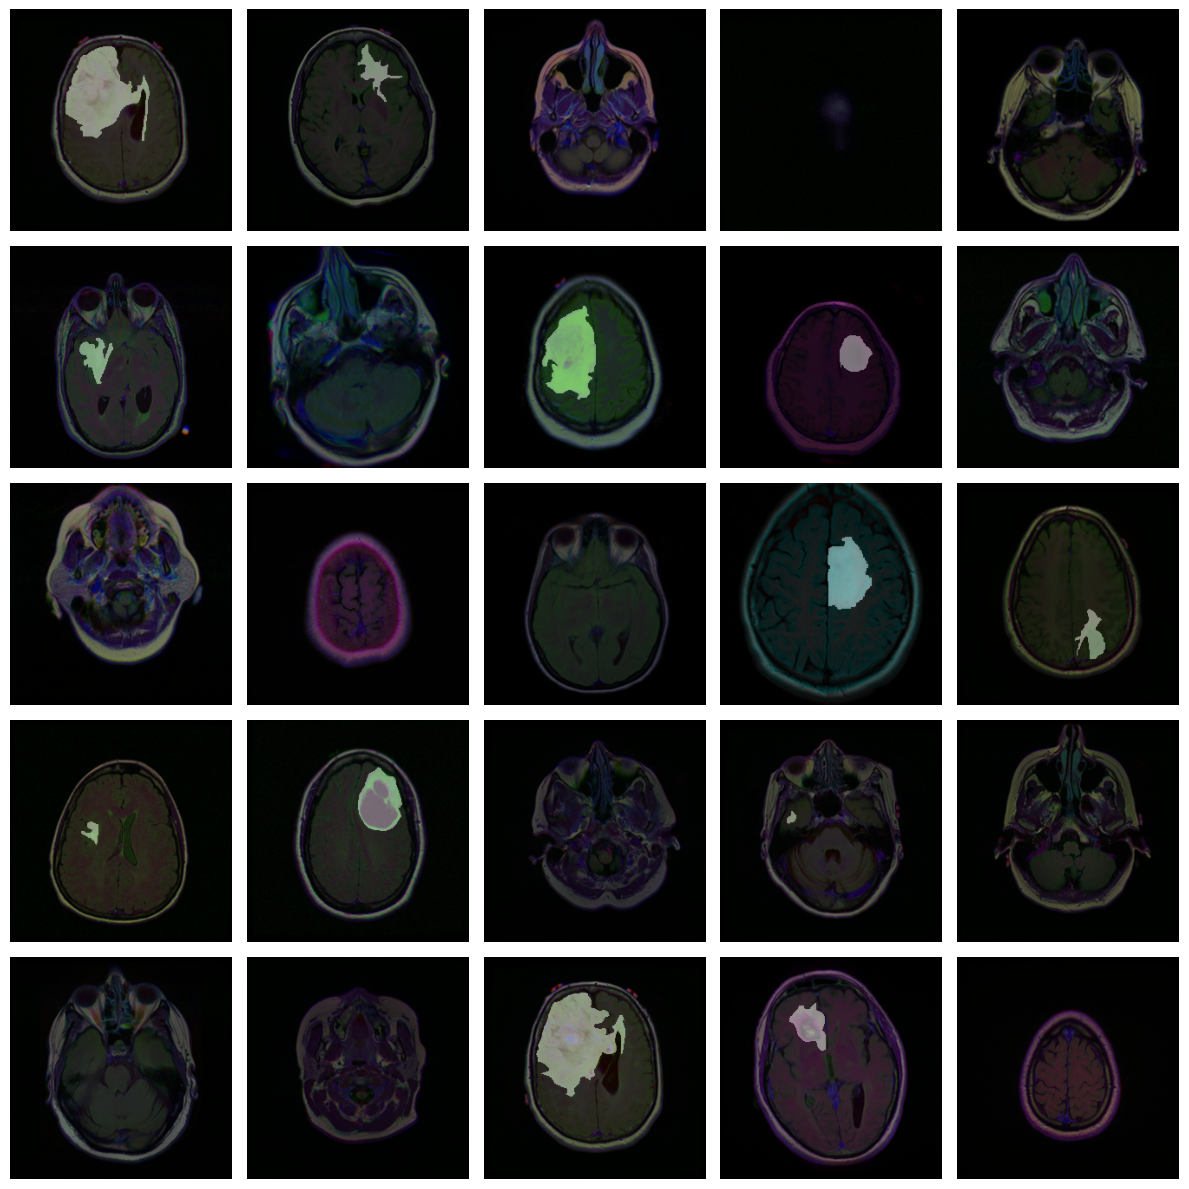

In [18]:
data_dir = '/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m'

df = create_df(data_dir)
train_df, valid_df, test_df = split_df(df)


tr_aug_dict = dict(rotation_range=0.2,
                            width_shift_range=0.05,
                            height_shift_range=0.05,
                            shear_range=0.05,
                            zoom_range=0.05,
                            horizontal_flip=True,
                            fill_mode='nearest')


train_gen = create_gens(train_df, aug_dict=tr_aug_dict)
valid_gen = create_gens(valid_df, aug_dict={})
test_gen = create_gens(test_df, aug_dict={})

show_images(list(train_df['images_paths']), list(train_df['masks_paths']))

# 🏗️ 4) Model Architecture (U-Net)

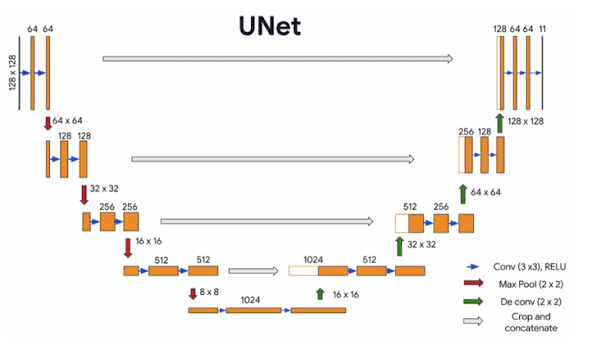

In [19]:
def unet(input_size = (256,256,3)):
    inputs = tf.keras.layers.Input(input_size)

    #Contraction path
    c1 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(inputs)
    c1 = tf.keras.layers.Dropout(0.1)(c1)
    c1 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c1)
    p1 = tf.keras.layers.MaxPooling2D((2, 2))(c1)

    c2 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p1)
    c2 = tf.keras.layers.Dropout(0.1)(c2)
    c2 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c2)
    p2 = tf.keras.layers.MaxPooling2D((2, 2))(c2)

    c3 = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p2)
    c3 = tf.keras.layers.Dropout(0.2)(c3)
    c3 = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c3)
    p3 = tf.keras.layers.MaxPooling2D((2, 2))(c3)

    c4 = tf.keras.layers.Conv2D(512, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p3)
    c4 = tf.keras.layers.Dropout(0.2)(c4)
    c4 = tf.keras.layers.Conv2D(512, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c4)
    p4 = tf.keras.layers.MaxPooling2D(pool_size=(2, 2))(c4)

    c5 = tf.keras.layers.Conv2D(1024, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p4)
    c5 = tf.keras.layers.Dropout(0.3)(c5)
    c5 = tf.keras.layers.Conv2D(1024, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c5)

    #Expansive path 
    u6 = tf.keras.layers.Conv2DTranspose(512, (2, 2), strides=(2, 2), padding='same')(c5)
    u6 = tf.keras.layers.concatenate([u6, c4])
    c6 = tf.keras.layers.Conv2D(512, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u6)
    c6 = tf.keras.layers.Dropout(0.2)(c6)
    c6 = tf.keras.layers.Conv2D(512, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c6)

    u7 = tf.keras.layers.Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = tf.keras.layers.concatenate([u7, c3])
    c7 = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u7)
    c7 = tf.keras.layers.Dropout(0.2)(c7)
    c7 = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c7)

    u8 = tf.keras.layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c7)
    u8 = tf.keras.layers.concatenate([u8, c2])
    c8 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u8)
    c8 = tf.keras.layers.Dropout(0.1)(c8)
    c8 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c8)

    u9 = tf.keras.layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c8)
    u9 = tf.keras.layers.concatenate([u9, c1])
    c9 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u9)
    c9 = tf.keras.layers.Dropout(0.1)(c9)
    c9 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c9)

    outputs = tf.keras.layers.Conv2D(1, (1, 1), activation='sigmoid')(c9)

    model = tf.keras.Model(inputs=[inputs], outputs=[outputs])
    return model

In [20]:
model = unet(input_size=(256, 256, 3))

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 256, 256,  │      1,792 │ input_layer_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 256, 256,  │          0 │ conv2d_19[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 256, 256,  │     36,928 │ dropout_9[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 128, 128,  │          0 │ conv2d_20[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 128, 128,  │     73,856 │ max_pooling2d_4[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 128, 128,  │          0 │ conv2d_21[0][0]   │
│ (Dropout)           │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 128, 128,  │    147,584 │ dropout_10[0][0]  │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 64, 64,    │          0 │ conv2d_22[0][0]   │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 64, 64,    │    295,168 │ max_pooling2d_5[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 64, 64,    │          0 │ conv2d_23[0][0]   │
│ (Dropout)           │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 64, 64,    │    590,080 │ dropout_11[0][0]  │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 32, 32,    │          0 │ conv2d_24[0][0]   │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 32, 32,    │  1,180,160 │ max_pooling2d_6[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 32, 32,    │          0 │ conv2d_25[0][0]   │
│ (Dropout)           │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_26 (Conv2D)  │ (None, 32, 32,    │  2,359,808 │ dropout_12[0][0]  │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 16, 16,    │          0 │ conv2d_26[0][0] 

 Total params: 31,031,745 (118.38 MB)

 Trainable params: 31,031,745 (118.38 MB)

 Non-trainable params: 0 (0.00 B)

# 5) Callbacks

In [21]:
EarlyStop=tf.keras.callbacks.EarlyStopping(patience=10,restore_best_weights=True)
Reduce_LR=tf.keras.callbacks.ReduceLROnPlateau(monitor='val_accuracy',verbose=2,factor=0.5,min_lr=0.00001)
model_check=tf.keras.callbacks.ModelCheckpoint('model.keras',monitor='val_loss',verbose=1,save_best_only=True)

callback=[EarlyStop , Reduce_LR , model_check]

# 📊 6) Custom Metrics & Loss Functions

In [26]:
import tensorflow as tf

# 1. تعريف الـ Dice Coefficient
def dice_coefficients(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    
    y_true_f = tf.cast(y_true_f, tf.float32)
    y_pred_f = tf.cast(y_pred_f, tf.float32)
    
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

# 2. تعريف الـ Dice Loss
def dice_loss(y_true, y_pred):
    return 1.0 - dice_coefficients(y_true, y_pred)

# 3. تعريف الـ IoU
def iou(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    
    y_true_f = tf.cast(y_true_f, tf.float32)
    y_pred_f = tf.cast(y_pred_f, tf.float32)
    
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

# 4. الـ Hybrid Loss
def bce_dice_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    # الـ BCE بيطلع مصفوفة، بناخد المتوسط بتاعها عشان نجمعها مع الـ Dice
    bce = tf.reduce_mean(bce) 
    
    dice = dice_loss(y_true, y_pred)
    return bce + dice

In [27]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=bce_dice_loss, 
    metrics=[dice_coefficients, iou, 'accuracy']
)

print("Model is compiled and ready for training!")

Model is compiled and ready for training!


In [28]:
train_steps = len(train_df) // 32
val_steps = len(valid_df) // 32

# 🚀 7) Model Training

In [29]:
history = model.fit(
    train_gen,
    steps_per_epoch=train_steps,
    epochs=50,
    validation_data=valid_gen,
    validation_steps=val_steps,
    callbacks=callback 
)

Epoch 1/50


I0000 00:00:1776465307.846288     170 service.cc:152] XLA service 0x78686c027190 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776465307.846327     170 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776465307.846331     170 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1776465309.277275     170 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-17 22:35:18.066157: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng12{k11=2} for conv %cudnn-conv-bias-activation.60 = (f32[32,128,128,128]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,128,128,128]{3,2,1,0} %bitcast.32342, f32[128,128,3,3]{3,2,1,0} %bitcast.30465, f32[128]{0} %bitcast.32402), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="functional_1_1/conv2d_22_1/convoluti

96/98 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - accuracy: 0.9379 - dice_coefficients: 0.0194 - iou: 0.0100 - loss: 1.2296

2026-04-17 22:40:30.767710: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-17 22:40:30.999186: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-17 22:40:32.198708: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-17 22:40:32.510669: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-17 22:40:42.551303: E external/local_xla/xla/stream_

98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9387 - dice_coefficients: 0.0201 - iou: 0.0104 - loss: 1.2266Found 393 validated image filenames.
Found 393 validated image filenames.

Epoch 1: val_loss improved from inf to 0.88320, saving model to model.keras
98/98 ━━━━━━━━━━━━━━━━━━━━ 435s 3s/step - accuracy: 0.9391 - dice_coefficients: 0.0205 - iou: 0.0106 - loss: 1.2252 - val_accuracy: 0.9898 - val_dice_coefficients: 0.1577 - val_iou: 0.0862 - val_loss: 0.8832 - learning_rate: 1.0000e-04
Epoch 2/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9892 - dice_coefficients: 0.3375 - iou: 0.2137 - loss: 0.7128
Epoch 2: val_loss improved from 0.88320 to 0.55106, saving model to model.keras
98/98 ━━━━━━━━━━━━━━━━━━━━ 179s 2s/step - accuracy: 0.9892 - dice_coefficients: 0.3384 - iou: 0.2144 - loss: 0.7120 - val_accuracy: 0.9897 - val_dice_coefficients: 0.4982 - val_iou: 0.3366 - val_loss: 0.5511 - learning_rate: 1.0000e-04
Epoch 3/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy

2026-04-17 22:48:11.969349: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-17 22:48:12.204669: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-17 22:48:13.539181: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-17 22:48:13.854772: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-17 22:48:24.466292: E external/local_xla/xla/stream_


Epoch 3: val_loss did not improve from 0.55106
98/98 ━━━━━━━━━━━━━━━━━━━━ 198s 2s/step - accuracy: 0.9910 - dice_coefficients: 0.5108 - iou: 0.3516 - loss: 0.5423 - val_accuracy: 0.9853 - val_dice_coefficients: 0.4743 - val_iou: 0.3146 - val_loss: 0.5883 - learning_rate: 1.0000e-04
Epoch 4/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9915 - dice_coefficients: 0.5452 - iou: 0.3891 - loss: 0.4860
Epoch 4: val_loss improved from 0.55106 to 0.44088, saving model to model.keras
98/98 ━━━━━━━━━━━━━━━━━━━━ 179s 2s/step - accuracy: 0.9915 - dice_coefficients: 0.5456 - iou: 0.3895 - loss: 0.4857 - val_accuracy: 0.9922 - val_dice_coefficients: 0.6029 - val_iou: 0.4350 - val_loss: 0.4409 - learning_rate: 1.0000e-04
Epoch 5/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9932 - dice_coefficients: 0.6367 - iou: 0.4753 - loss: 0.4113
Epoch 5: val_loss improved from 0.44088 to 0.41083, saving model to model.keras
98/98 ━━━━━━━━━━━━━━━━━━━━ 178s 2s/step - accuracy: 0.9932 - dice_coef

# 📈 8) Training Results

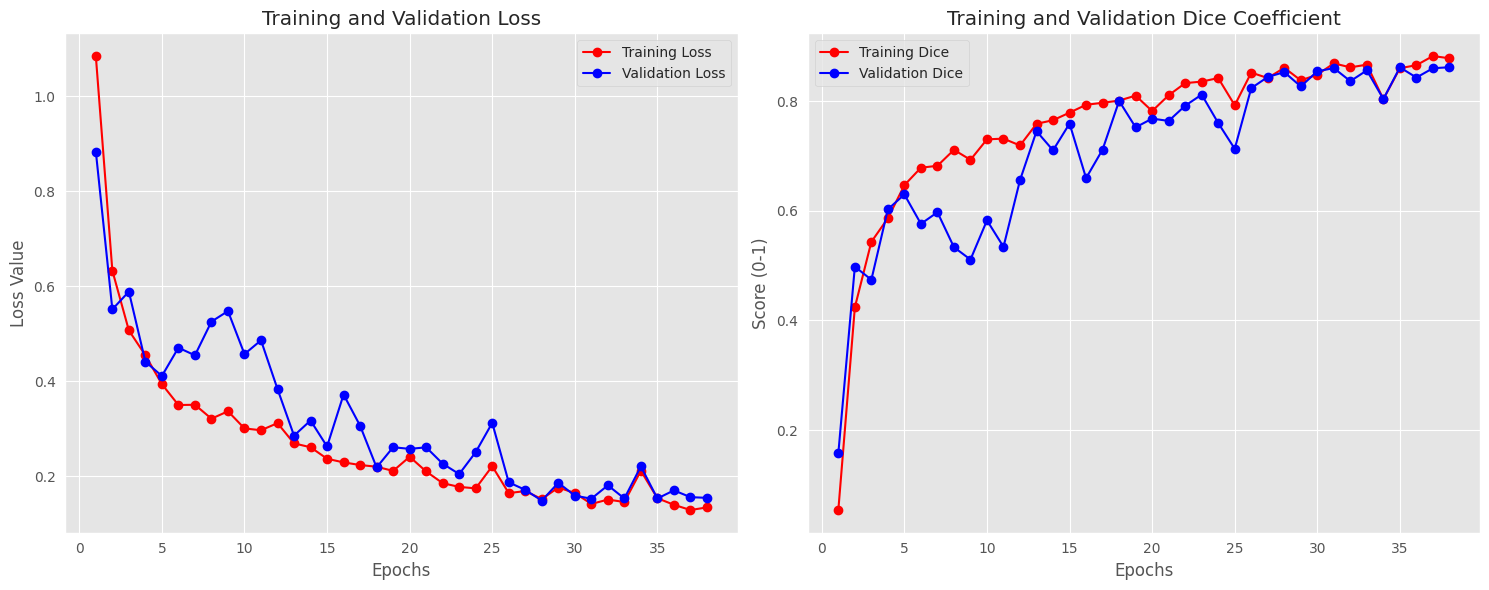

In [30]:
import matplotlib.pyplot as plt

# تحديد استايل الرسم
plt.style.use('ggplot')

def plot_learning_curves(history):
    epochs = range(1, len(history.history['loss']) + 1)
    
    plt.figure(figsize=(15, 6))

    # 1. رسم الـ Loss (BCE + Dice Loss)
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history.history['loss'], 'r-o', label='Training Loss')
    plt.plot(epochs, history.history['val_loss'], 'b-o', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss Value')
    plt.legend()
    plt.grid(True)

    # 2. رسم الـ Dice Coefficient
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history.history['dice_coefficients'], 'r-o', label='Training Dice')
    plt.plot(epochs, history.history['val_dice_coefficients'], 'b-o', label='Validation Dice')
    plt.title('Training and Validation Dice Coefficient')
    plt.xlabel('Epochs')
    plt.ylabel('Score (0-1)')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# استدعاء الدالة
plot_learning_curves(history)

# 🔍 9) Model Inference & Visualization

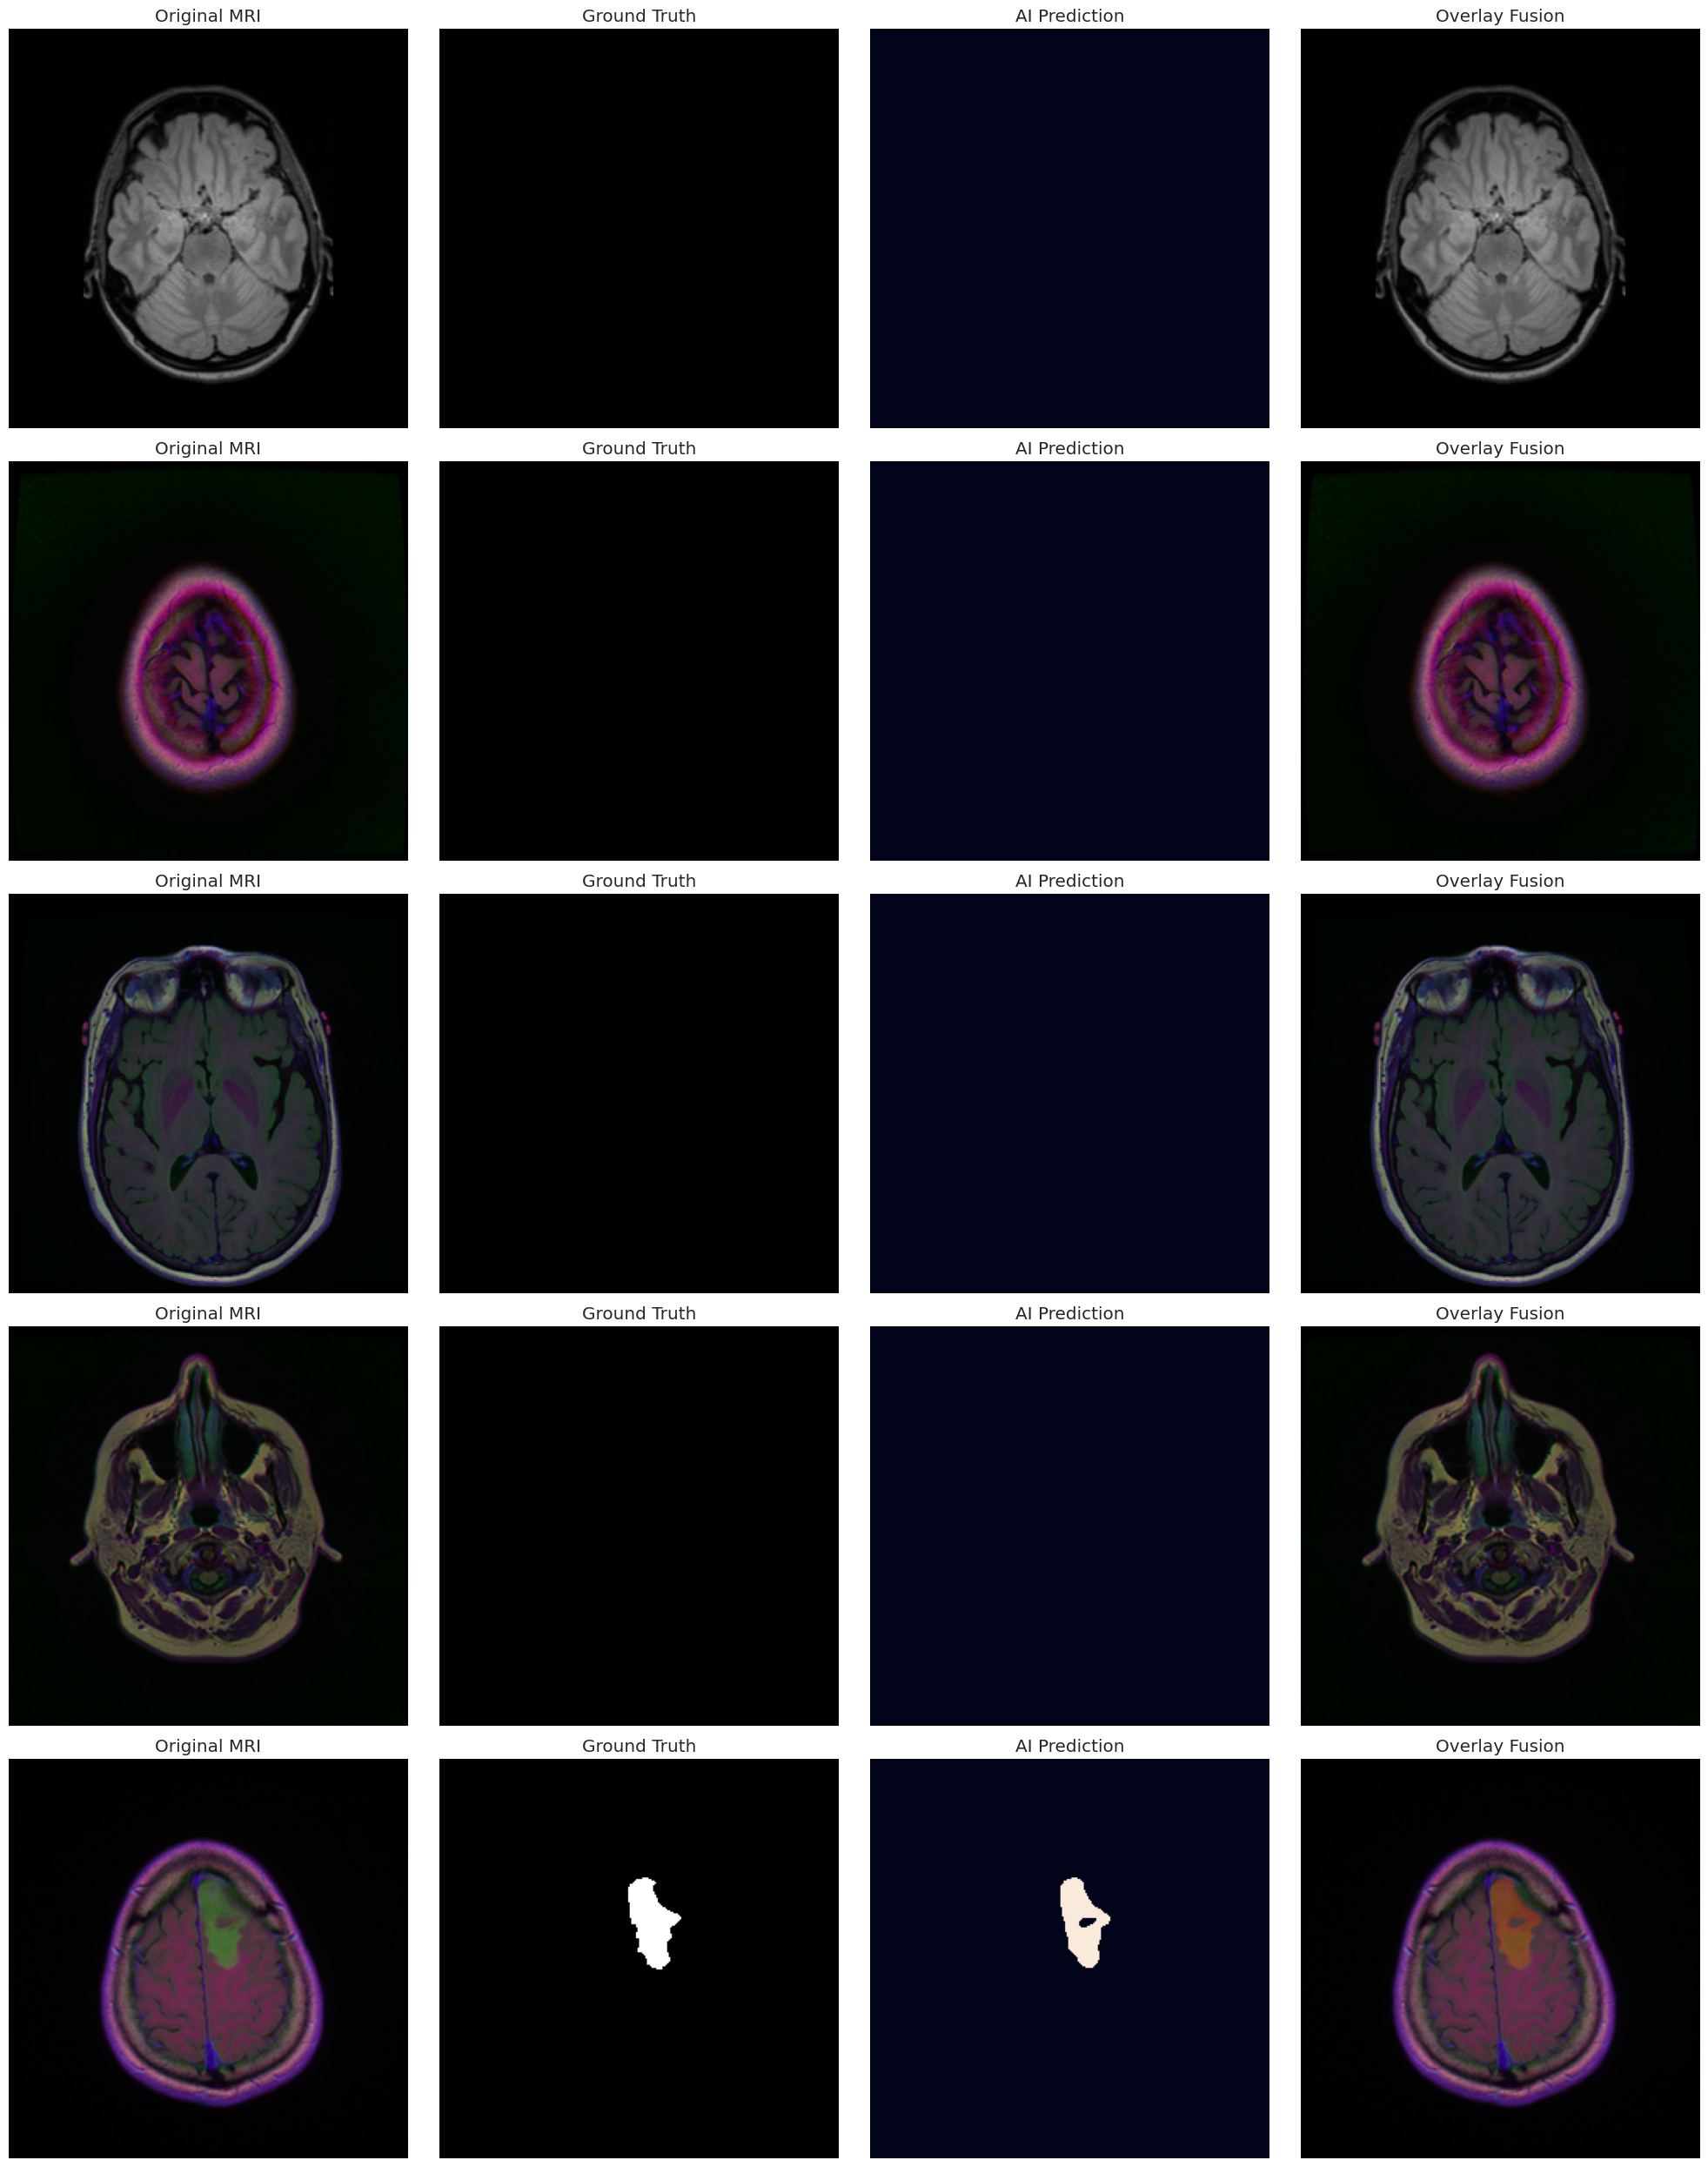

In [39]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def plot_final_results(test_df, model, n=5):
    plt.figure(figsize=(20, n * 5))
    
    for i in range(n):
        idx = np.random.randint(0, len(test_df))
        img_path = test_df.iloc[idx]['images_paths']
        mask_path = test_df.iloc[idx]['masks_paths']
        
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_res = cv2.resize(img, (256, 256))
        img_input = img_res / 255.0
        img_input = np.expand_dims(img_input, axis=0)
        
        true_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        true_mask = cv2.resize(true_mask, (256, 256))
        
        pred_mask = model.predict(img_input, verbose=0)[0]
        pred_mask = (pred_mask > 0.5).astype(np.uint8)
        
        overlay = img_res.copy()
        overlay[pred_mask[:,:,0] == 1] = [255, 0, 0] 
        fusion = cv2.addWeighted(img_res, 0.7, overlay, 0.3, 0) 
        
        titles = ['Original MRI', 'Ground Truth', 'AI Prediction', 'Overlay Fusion']
        images = [img_res, true_mask, pred_mask, fusion]
        
        for j in range(4):
            plt.subplot(n, 4, i*4 + j + 1)
            plt.imshow(images[j], cmap='gray' if j==1 else None)
            plt.title(titles[j])
            plt.axis('off')

    plt.tight_layout()
    plt.show()

plot_final_results(test_df, model)

# 10) Evaluating Model on Test Data

In [34]:
print("Evaluating Model on Test Set...")
results = model.evaluate(test_gen, steps=len(test_df)//32)

print(f"\n--- Final Test Metrics ---")
print(f"Test Loss: {results[0]:.4f}")
print(f"Test Accuracy: {results[1]:.4f}")
print(f"Test Dice Coefficient: {results[2]:.4f}")
print(f"Test IoU (Jaccard Index): {results[3]:.4f}")

Evaluating Model on Test Set...
Found 393 validated image filenames.
Found 393 validated image filenames.
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 673ms/step - accuracy: 0.9971 - dice_coefficients: 0.8257 - iou: 0.7065 - loss: 0.1872

--- Final Test Metrics ---
Test Loss: 0.1938
Test Accuracy: 0.8187
Test Dice Coefficient: 0.7008
Test IoU (Jaccard Index): 0.9972
